In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.shape
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [4]:
df.isnull().sum()
df['loan_status'].unique()

df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


<Axes: xlabel='loan_status', ylabel='count'>

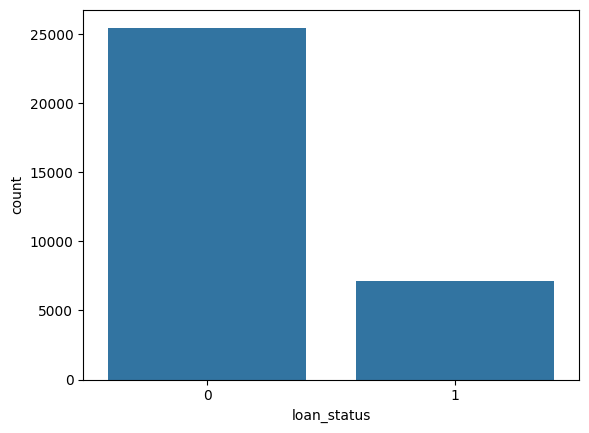

In [5]:
sns.countplot(x = 'loan_status', data=df)

In [6]:
(df['person_age']>100).sum()

np.int64(5)

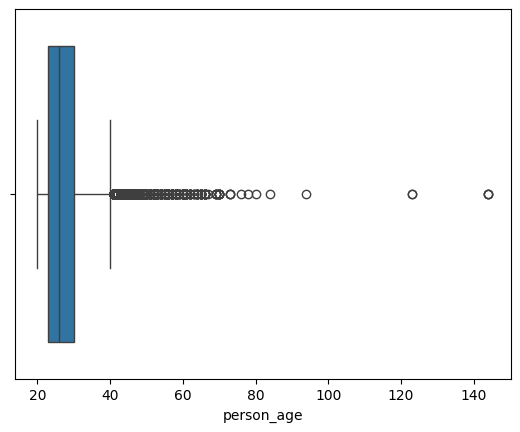

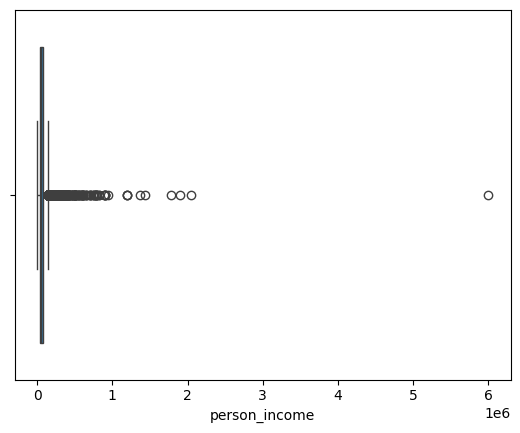

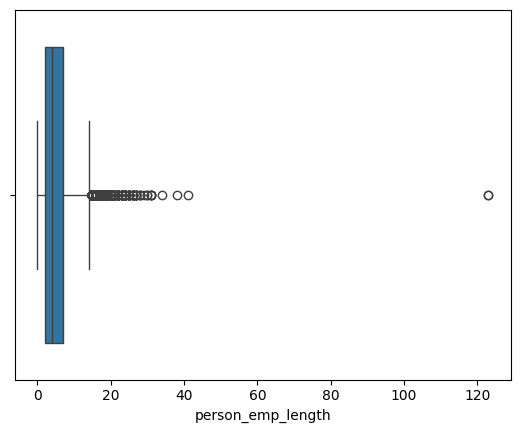

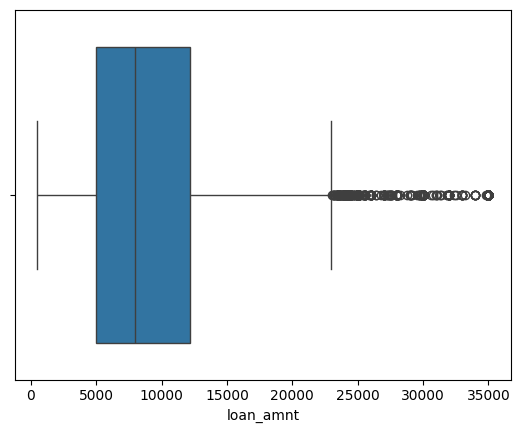

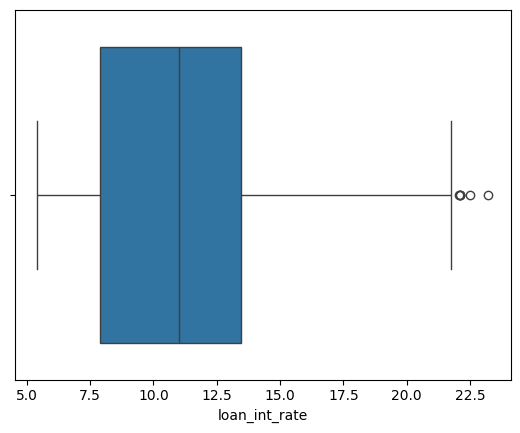

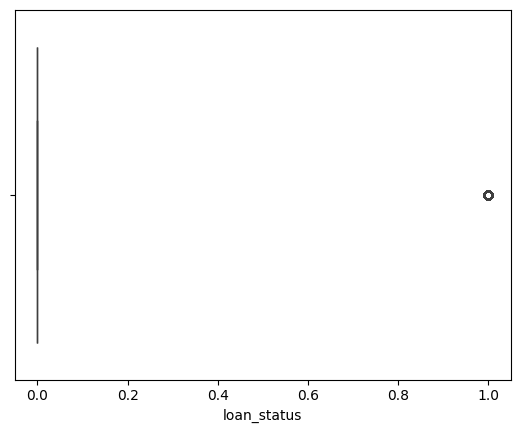

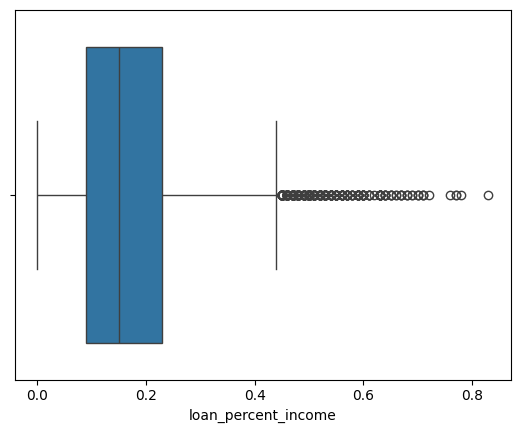

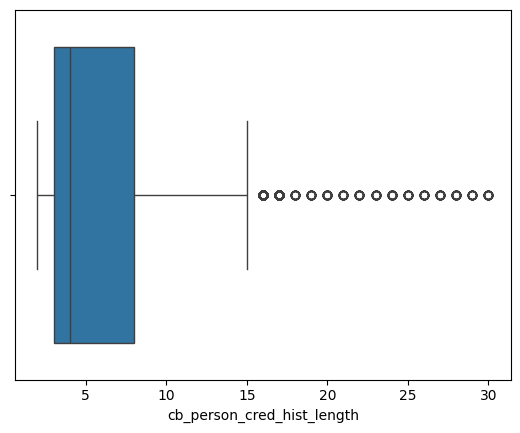

In [7]:
numerical_cols = df.select_dtypes(include=np.number).columns

for i in numerical_cols:
  sns.boxplot(x=df[i])
  plt.show()



In [8]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [9]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

<Axes: >

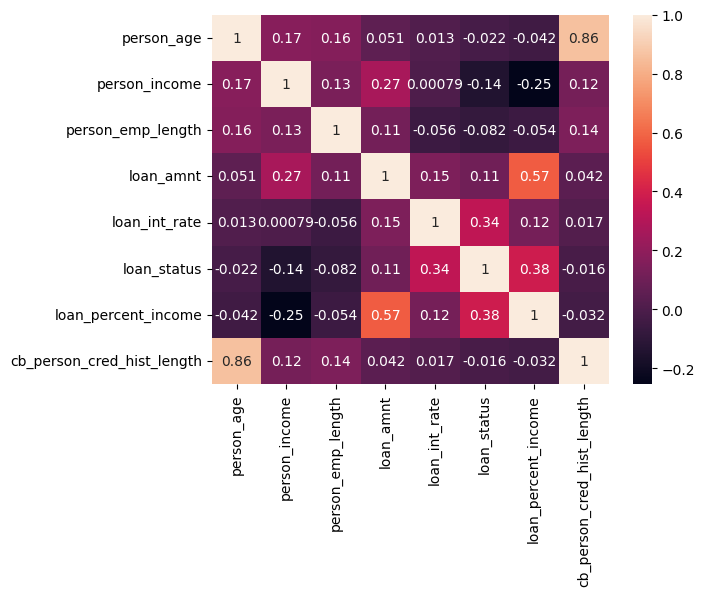

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [11]:
df_copy = df.copy()

print(f"Original Rows: {df_copy.shape[0]}")
df_copy.drop_duplicates(inplace=True)

print(f"Rows after removing duplicates: {df_copy.shape[0]}")

df_copy = df_copy[df_copy['person_age']>=18]
df_copy = df_copy[df_copy['person_age']<=100]

df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

df_copy = df_copy[df_copy['loan_amnt']>0]

print("Loan interest rate range from (min: 5.42 and max: 23.22)")



Original Rows: 32581
Rows after removing duplicates: 32416
Loan interest rate range from (min: 5.42 and max: 23.22)


In [12]:
df_copy.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31522.000000,3.152200e+04,31522.000000,31522.000000,28495.000000,31522.000000,31522.000000,31522.000000
mean,27.742529,6.650168e+04,4.782850,9663.771334,11.045220,0.215944,0.169658,5.816097
std,6.218713,5.275216e+04,4.037343,6334.787700,3.230786,0.411482,0.106296,4.063622
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.943800e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [13]:
X = df_copy.drop('loan_status', axis=1)
y= df_copy['loan_status']

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
numerical_cols = ['person_age',	'person_income',	'person_emp_length',	'loan_amnt',	'loan_int_rate',	'loan_percent_income',	'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

In [16]:
neg, pos = np.bincount(y_train)
scale_weights = neg/pos #class weight

In [17]:
y_train.value_counts()

,count
loan_status,
0,19772
1,5445


In [18]:
scale_weights

np.float64(3.6312213039485766)

In [19]:
#Logistic regression : impute + SCALE Numeric, impute + One Hot encoding
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
           ('imputer', SimpleImputer(strategy='median')),
           ('scaler', StandardScaler())
        ]), numerical_cols),
        ('cat', Pipeline([
           ('imputer', SimpleImputer(strategy='constant', fill_value="Missing")),
           ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

In [20]:

preprocessor_xg = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
           ('imputer', SimpleImputer(strategy='median'))
        ]), numerical_cols),
        ('cat', Pipeline([
           ('imputer', SimpleImputer(strategy='constant', fill_value="Missing")),
           ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

In [30]:
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve

def evaluate_model(model_name, model, X_test, y_test, threshold=None):
  y_pred = model.predict(X_test)
  y_pred_prob = model.predict_proba(X_test)[:, 1]

  if threshold is not None:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  conf_matrix = confusion_matrix(y_test, y_pred)
  class_report = classification_report(y_test, y_pred)

  print(f"{model_name} Metrics:")
  print(f"Best Threshold : {threshold}")
  print(f"Accuracy: {accuracy:.2f}")
  print(f"Precision: {precision:.2f}")
  print(f"Recall: {recall:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"Model: {model_name} Classification Report:")
  print(class_report)

  sns.heatmap(conf_matrix, annot=True, fmt="d")
  plt.title(f"{model_name} Confusion Matrix")
  plt.xlabel("Predicted Values")
  plt.ylabel("Actual Values")
  plt.show()

  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc': 'roc_auc', 'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}

In [23]:
from sklearn.linear_model import LogisticRegression
lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

In [24]:
from xgboost import XGBClassifier
xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(n_estimator=300, max_depth=5, learning_rate=0.1, random_state=42, scale_pos_weight=scale_weights, ))
])

In [25]:
for cv_name, pipe in [("Logistic Regression", lr_cv_pipeline),
                      ("XGBoost", xgb_cv_pipeline)]:
                      cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)

                      print(cv_name)
                      print(f"ROC_AUC: {cv_results['test_roc_auc'].mean()}")
                      print(f"Accuracy: {cv_results['test_accuracy'].mean()}")
                      print(f"Precision: {cv_results['test_precision'].mean()}")
                      print(f"Recall: {cv_results['test_recall'].mean()}")
                      print(f"F1: {cv_results['test_f1'].mean()}")
                      print()


Logistic Regression
ROC_AUC: 0.8705112830525306
Accuracy: 0.8115949542892269
Precision: 0.5448226008889892
Recall: 0.7781450872359963
F1: 0.6408013995933108



/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [12:03:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [12:03:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [12:03:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [12:03:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [12:03

XGBoost
ROC_AUC: 0.9393848243386111
Accuracy: 0.9086724038455642
Precision: 0.7913354492271174
Recall: 0.7856749311294765
F1: 0.7880291923045915



In [26]:
cv_results

{'fit_time': array([0.37101984, 0.32901978, 0.30892205, 0.29137826, 0.3827641 ]),
 'score_time': array([0.07122755, 0.07204008, 0.06745934, 0.07144761, 0.07796979]),
 'test_roc_auc': array([0.94306506, 0.93043619, 0.94080108, 0.94479977, 0.93782203]),
 'test_accuracy': array([0.9129659 , 0.91237113, 0.90838786, 0.9109657 , 0.89867143]),
 'test_precision': array([0.80545113, 0.82317682, 0.79000925, 0.78933092, 0.74870912]),
 'test_recall': array([0.78696051, 0.75665748, 0.78420569, 0.80165289, 0.79889807]),
 'test_f1': array([0.79609847, 0.78851675, 0.78709677, 0.79544419, 0.77298978])}

In [27]:
from sklearn.pipeline import Pipeline

baseline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression( class_weight="balanced"))
])
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

In [28]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier( learning_rate=0.1, scale_pos_weight=scale_weights, random_state=42 ))
])
xg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

Baseline Logistic Model Metrics:
Best Threshold : None
Accuracy: 0.82
Precision: 0.56
Recall: 0.79
F1 : 0.65

Model: Baseline Logistic Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



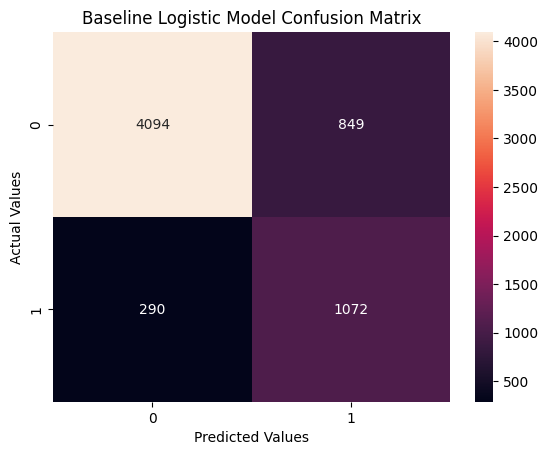

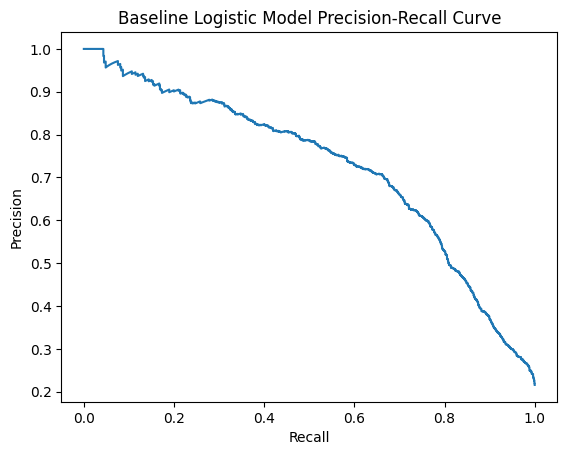

In [31]:
evaluate_model("Baseline Logistic Model", baseline_model, X_test, y_test)

XGBoost Metrics:
Best Threshold : None
Accuracy: 0.92
Precision: 0.82
Recall: 0.79
F1 : 0.81

Model: XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      4943
           1       0.82      0.79      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.87      0.88      6305
weighted avg       0.92      0.92      0.92      6305



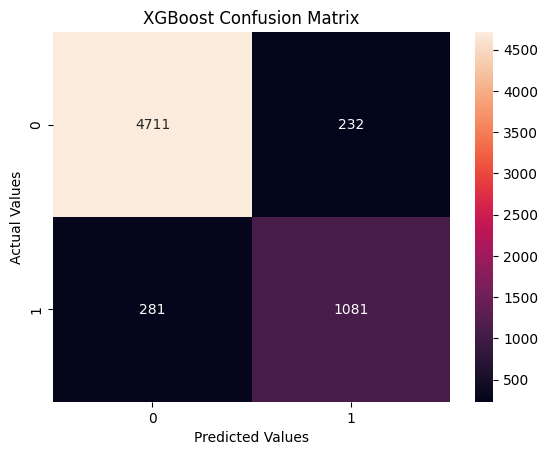

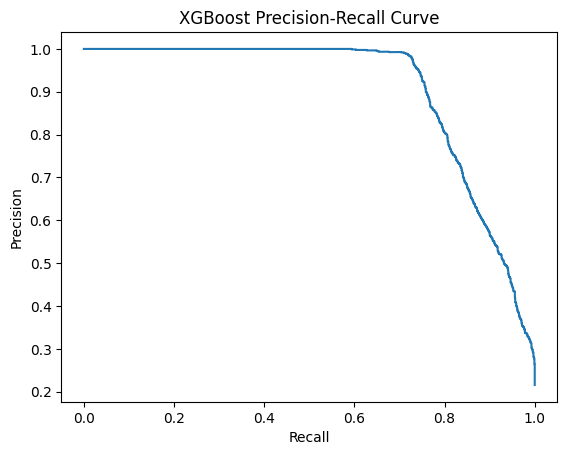

In [32]:
evaluate_model("XGBoost", xg_model, X_test, y_test)

In [33]:
#Hyperparameter tuning

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
param_grid = {
    'classifier__n_estimators': randint(150, 600),
    'classifier__max_depth':randint(3, 9),
    'classifier__learning_rate': uniform(0.01, 0.5),
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__colsample_bytree': uniform(0.6, 0.4),
    'classifier__min_child_weight': randint(1, 10),
    'classifier__gamma': uniform(0, 5)
}


In [34]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring='average_precision',
    n_jobs=1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7aea2e1e8550>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7aea32fd74d0>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7aea2e1e8190>},
                   scoring='average_precision', verbose=1)

In [35]:
print(f"Score after performing Tuning {random_search.best_score_:.2f}")

Score after performing Tuning 0.90


In [36]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.8190371333789064),
 'classifier__gamma': np.float64(0.41436997208351756),
 'classifier__learning_rate': np.float64(0.08832360873346055),
 'classifier__max_depth': 8,
 'classifier__min_child_weight': 6,
 'classifier__n_estimators': 253,
 'classifier__subsample': np.float64(0.9638517020376561)}

Logistic Regression Metrics:
Best Threshold : None
Accuracy: 0.82
Precision: 0.56
Recall: 0.79
F1 : 0.65

Model: Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



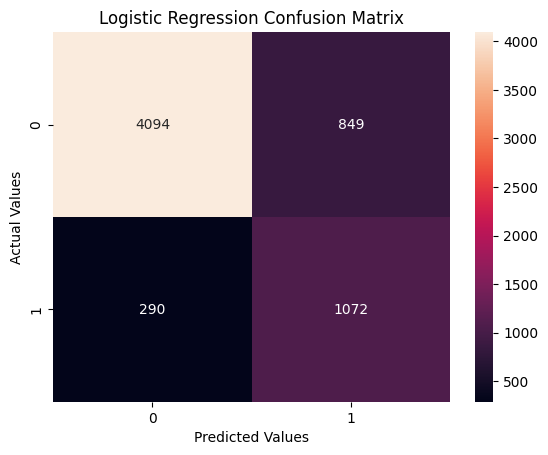

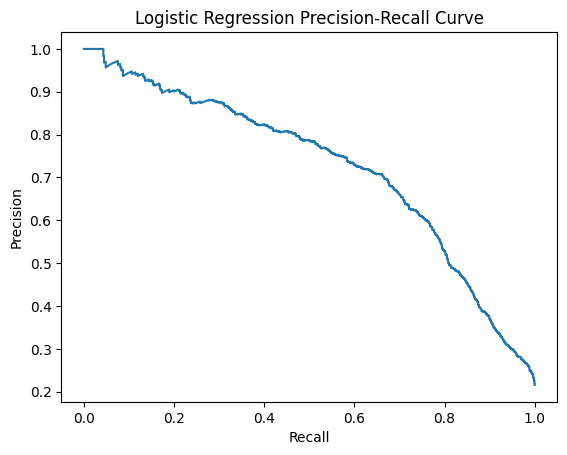

In [37]:
evaluate_model("Logistic Regression", baseline_model, X_test, y_test)

XGBoost Metrics:
Best Threshold : None
Accuracy: 0.93
Precision: 0.86
Recall: 0.79
F1 : 0.83

Model: XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      4943
           1       0.86      0.79      0.83      1362

    accuracy                           0.93      6305
   macro avg       0.90      0.88      0.89      6305
weighted avg       0.93      0.93      0.93      6305



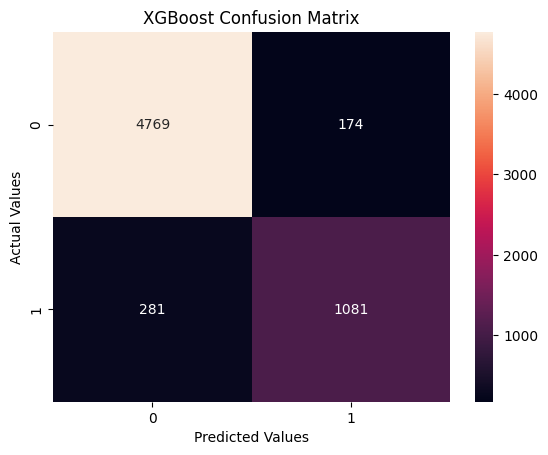

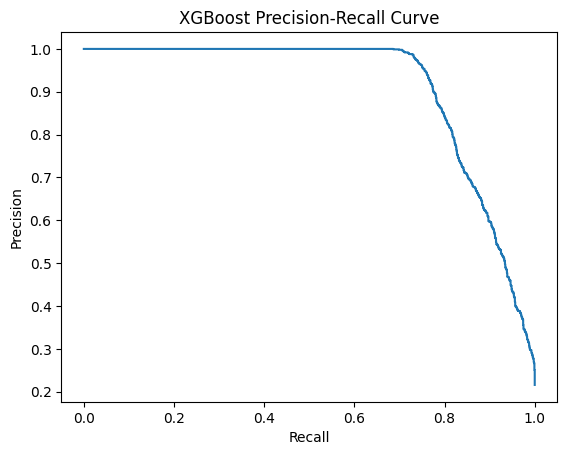

In [38]:
evaluate_model("XGBoost", random_search, X_test, y_test)

In [39]:
def evaluate_model(model_name, model, X_test, y_test, threshold=0.5):

  prob = xg_model.predict_proba(X_test)[:, 1]
  y_pred = (prob >= threshold).astype(int)

  precisions, recalls, threshold = precision_recall_curve(y_test, prob)


  f1 = 2 * (precisions-recalls) / (precisions + recalls + 1e-9)
  f1

  best = np.argmax(f1[:-1])
  best_threshold = threshold[best]

  evaluate_model("XGBoost", xg_model, X_test, y_test, best_threshold)

In [40]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)


CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.08832360873346055),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=8,
                                                                max_leaves=None,
                                                                min_child_weight=6,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=253,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [41]:
uncalibrated = xg_model.predict_proba(X_test)[:, 1]
calibrated = calibrated_model.predict_proba(X_test)[:, 1]

In [42]:
calibrated

array([0.43397079, 0.02828287, 0.9547581 , ..., 0.49337605, 0.02091615,
       0.01761304])

In [43]:
uncalibrated

array([0.8254656 , 0.25111562, 0.9782833 , ..., 0.48520026, 0.07587515,
       0.05467961], dtype=float32)

In [44]:
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)
actual_cal, predicted_cal = calibration_curve(y_test, calibrated, n_bins=10)

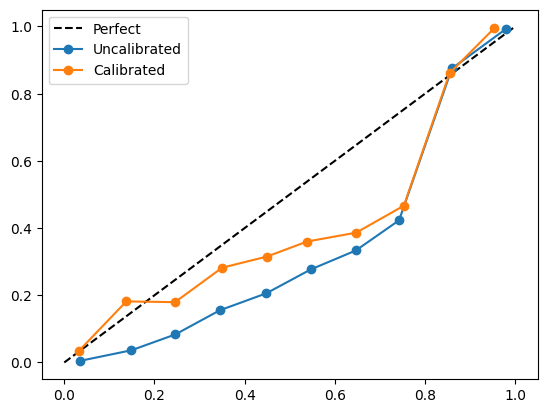

In [45]:
plt.plot([0, 1], [0,1], 'k--', label="Perfect")

plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label="Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label="Calibrated"
)

plt.legend()

In [46]:
#SHAP tells which features pushed the predictions up n down and how much. global and local explanation

!pip install shap
import shap

In [47]:
xgb_classifier = xg_model.named_steps['classifier']


In [48]:
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)

In [49]:
feature_names = xg_model.named_steps['preprocessor'].get_feature_names_out()

In [50]:
#convert to df for clean shap plots

X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)
X_test_df

,num__person_age,num__person_income,num__person_emp_length,num__loan_amnt,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,...,cat__loan_intent_VENTURE,cat__loan_grade_A,cat__loan_grade_B,cat__loan_grade_C,cat__loan_grade_D,cat__loan_grade_E,cat__loan_grade_F,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y
0,24.0,30000.0,1.0,15000.0,15.68,0.50,3.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,23.0,60000.0,6.0,25600.0,10.99,0.43,4.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,29.0,18000.0,2.0,3600.0,15.27,0.20,6.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,32.0,130000.0,7.0,13000.0,12.69,0.10,8.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,23.0,45288.0,7.0,20500.0,9.25,0.45,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6300,21.0,75000.0,5.0,20000.0,13.11,0.27,2.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
6301,29.0,265000.0,2.0,25000.0,11.26,0.09,10.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6302,25.0,48996.0,8.0,5000.0,9.88,0.10,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6303,27.0,115000.0,11.0,8000.0,7.51,0.07,7.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [51]:
#shap explainer create built for tree-based model

explainer = shap.TreeExplainer(xgb_classifier)

In [52]:
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[-1.7525564e-01, -1.0555401e-01,  1.2984274e-01, ...,
        -7.3516299e-03, -3.8879909e-02,  0.0000000e+00],
       [ 4.7165085e-02, -8.7262326e-01, -9.4737314e-02, ...,
        -9.2151780e-03, -7.5508673e-03,  0.0000000e+00],
       [ 7.8027323e-02,  3.5025654e+00,  1.2711690e-01, ...,
        -7.3584518e-03,  7.7456667e-04,  0.0000000e+00],
       ...,
       [-8.6244913e-03,  5.8208084e-01,  7.2391242e-02, ...,
        -9.2837382e-03, -1.1459960e-02,  0.0000000e+00],
       [ 2.0838849e-02, -1.0313793e+00,  4.3692421e-02, ...,
        -9.2305308e-03, -1.1398584e-02,  0.0000000e+00],
       [-1.3665082e-01, -5.0866711e-01,  2.6854105e-02, ...,
        -8.8342456e-03, -1.0388625e-02,  0.0000000e+00]], dtype=float32)

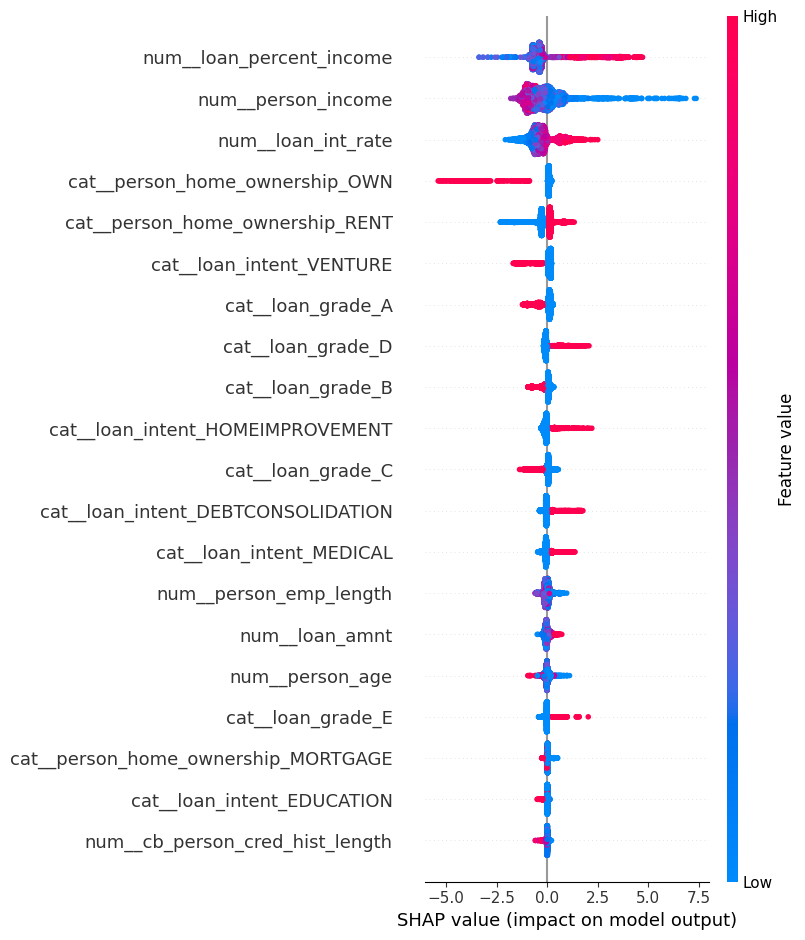

In [53]:
shap.summary_plot(shap_values, X_test_df)

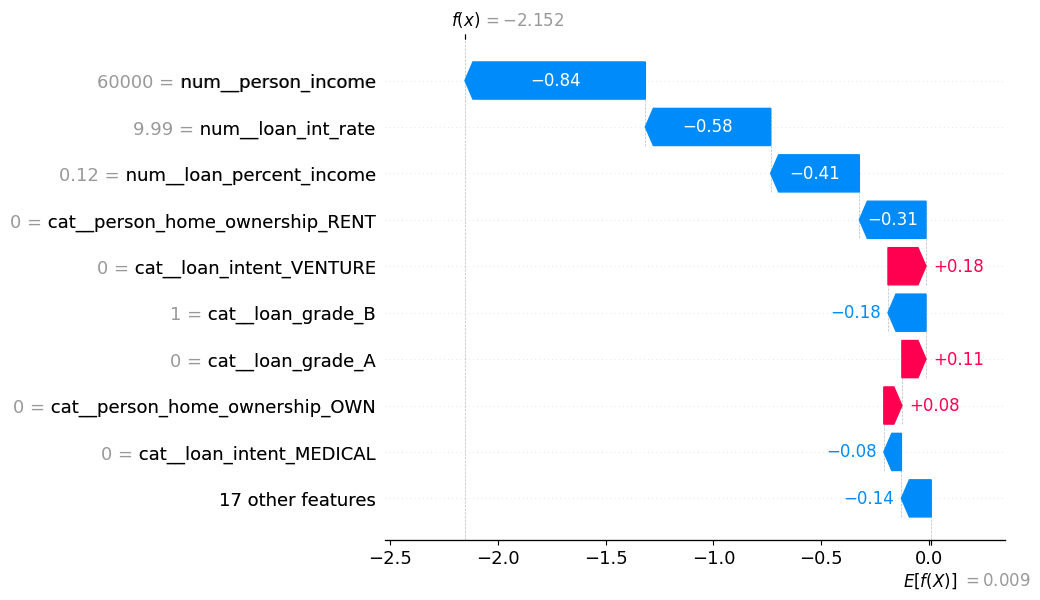

In [54]:
row_index = 5

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[row_index],
        base_values=explainer.expected_value,
        data=X_test_df.iloc[row_index],
        feature_names=feature_names
    )
)

In [55]:
y_pred = random_search.predict(X_test)

In [56]:
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [57]:
result_df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,actual,predicted
14455,24,30000,OWN,1.0,MEDICAL,E,15000,15.68,0.50,N,3,1,1
8701,23,60000,MORTGAGE,6.0,EDUCATION,C,25600,NaN,0.43,N,4,0,0
19804,29,18000,RENT,2.0,EDUCATION,C,3600,15.27,0.20,N,6,1,1
27252,32,130000,MORTGAGE,7.0,MEDICAL,B,13000,12.69,0.10,N,8,0,0
5610,23,45288,MORTGAGE,7.0,DEBTCONSOLIDATION,B,20500,9.25,0.45,N,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11661,21,75000,MORTGAGE,5.0,PERSONAL,C,20000,13.11,0.27,Y,2,0,0
27837,29,265000,MORTGAGE,2.0,PERSONAL,B,25000,11.26,0.09,N,10,0,0
17192,25,48996,MORTGAGE,8.0,MEDICAL,B,5000,9.88,0.10,N,2,1,1
26858,27,115000,MORTGAGE,11.0,MEDICAL,A,8000,7.51,0.07,N,7,0,0


In [58]:
false_positive = result_df[(result_df['actual']==0) & (result_df['predicted']==1)]

false_negative = result_df[(result_df['actual']==1) & (result_df['predicted']==0)]

In [59]:
print(f"False Positive: {len(false_positive)}")
print(f"False Negative: {len(false_negative)}")

False Positive: 174
False Negative: 281


In [185]:
#false negative > false positive

In [60]:
import joblib
joblib.dump(calibrated_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [62]:
best_threshold = 0.5

joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']